In [1]:
import gdown
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from MLP import *

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
Folder = 'data/'

In [4]:
FILE_ID = '1BYk7DcE5uJuJq3cnOLrjlCbeq6J_V6k7'
FILE_NAME = 'NonLinear_data.npy'

In [5]:
gdown.download(id= FILE_ID, output=Folder + FILE_NAME)

Downloading...
From: https://drive.google.com/uc?id=1BYk7DcE5uJuJq3cnOLrjlCbeq6J_V6k7
To: d:\Exercise-Week3-Module-5\data\NonLinear_data.npy
100%|██████████| 5.57k/5.57k [00:00<00:00, 3.65MB/s]


'data/NonLinear_data.npy'

In [6]:
data = np.load(Folder + FILE_NAME, allow_pickle=True).item()
data

{'X': array([[ 0.00000000e+00,  0.00000000e+00],
        [ 9.60083739e-04,  1.00552794e-02],
        [ 1.04586376e-02,  1.72840539e-02],
        [ 8.79222065e-04,  3.02902726e-02],
        [ 9.91726687e-03,  3.91680265e-02],
        [ 6.77282958e-03,  5.00488652e-02],
        [ 1.41908220e-02,  5.89212623e-02],
        [ 3.11579559e-02,  6.34718176e-02],
        [-8.03243759e-03,  8.04078719e-02],
        [ 4.44744542e-02,  7.92873618e-02],
        [ 4.42749312e-02,  9.07897074e-02],
        [ 1.35659734e-02,  1.10279841e-01],
        [ 4.51006429e-02,  1.12509157e-01],
        [ 8.18222344e-02,  1.02704724e-01],
        [ 1.02915603e-01,  9.69862772e-02],
        [ 1.09463907e-01,  1.04759220e-01],
        [ 9.88552373e-02,  1.27857052e-01],
        [ 1.33913469e-01,  1.07489394e-01],
        [ 1.67286205e-01,  7.12262365e-02],
        [ 1.70560114e-01,  8.79899069e-02],
        [ 1.40953043e-01,  1.44721808e-01],
        [ 1.28611110e-01,  1.68684887e-01],
        [ 1.42427503e-01,  

In [7]:
print(data.keys())

dict_keys(['X', 'labels'])


In [8]:
X = data['X']
print(f"X = {X}")
y = data['labels']
print(f"y = {y}")

X = [[ 0.00000000e+00  0.00000000e+00]
 [ 9.60083739e-04  1.00552794e-02]
 [ 1.04586376e-02  1.72840539e-02]
 [ 8.79222065e-04  3.02902726e-02]
 [ 9.91726687e-03  3.91680265e-02]
 [ 6.77282958e-03  5.00488652e-02]
 [ 1.41908220e-02  5.89212623e-02]
 [ 3.11579559e-02  6.34718176e-02]
 [-8.03243759e-03  8.04078719e-02]
 [ 4.44744542e-02  7.92873618e-02]
 [ 4.42749312e-02  9.07897074e-02]
 [ 1.35659734e-02  1.10279841e-01]
 [ 4.51006429e-02  1.12509157e-01]
 [ 8.18222344e-02  1.02704724e-01]
 [ 1.02915603e-01  9.69862772e-02]
 [ 1.09463907e-01  1.04759220e-01]
 [ 9.88552373e-02  1.27857052e-01]
 [ 1.33913469e-01  1.07489394e-01]
 [ 1.67286205e-01  7.12262365e-02]
 [ 1.70560114e-01  8.79899069e-02]
 [ 1.40953043e-01  1.44721808e-01]
 [ 1.28611110e-01  1.68684887e-01]
 [ 1.42427503e-01  1.70578786e-01]
 [ 1.90889800e-01  1.32420423e-01]
 [ 1.87648899e-01  1.53484214e-01]
 [ 1.93996423e-01  1.61661347e-01]
 [ 2.35108650e-01  1.17031947e-01]
 [ 2.38113100e-01  1.32974874e-01]
 [ 2.06828734e-0

In [9]:
# In ra các nhãn của bộ DL
np.unique(y)

array([0, 1, 2], dtype=uint8)

# Mã hóa nhãn về dạng OneHot Encoding

In [10]:
Encoder = OneHotEncoder(categories=[np.arange(3)],sparse_output=False)

In [11]:
y_encoder = Encoder.fit_transform(y.reshape(-1,1))
y_encoder

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

# Chuẩn hóa các đặc trưng của bộ DL

In [12]:
# Chuẩn hóa DL
Scaler = StandardScaler()
X = Scaler.fit_transform(X.copy())
X

array([[ 4.07715390e-02,  7.49313770e-02],
       [ 4.30600889e-02,  1.00240659e-01],
       [ 6.57017753e-02,  1.18435588e-01],
       [ 4.28673391e-02,  1.51172427e-01],
       [ 6.44113108e-02,  1.73517861e-01],
       [ 5.69159211e-02,  2.00905088e-01],
       [ 7.45981768e-02,  2.23237038e-01],
       [ 1.15042704e-01,  2.34690851e-01],
       [ 2.16246314e-02,  2.77319143e-01],
       [ 1.46785218e-01,  2.74498802e-01],
       [ 1.46309616e-01,  3.03450371e-01],
       [ 7.31087262e-02,  3.52507317e-01],
       [ 1.48277863e-01,  3.58118536e-01],
       [ 2.35811057e-01,  3.33440640e-01],
       [ 2.86091284e-01,  3.19047226e-01],
       [ 3.01700463e-01,  3.38611836e-01],
       [ 2.76412596e-01,  3.96749409e-01],
       [ 3.59980843e-01,  3.45483721e-01],
       [ 4.39531376e-01,  2.54208835e-01],
       [ 4.47335387e-01,  2.96403233e-01],
       [ 3.76761063e-01,  4.39198241e-01],
       [ 3.47341618e-01,  4.99513654e-01],
       [ 3.80275731e-01,  5.04280626e-01],
       [ 4.

In [13]:
X = torch.tensor(X.copy(), dtype=torch.float32)
y = torch.tensor(y_encoder,dtype=torch.float32)

In [14]:
# Chia bộ DL thành train set và test set
print(X.shape)
print(y.shape)

torch.Size([300, 2])
torch.Size([300, 3])


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.1, random_state=42, shuffle=True)

In [16]:
# Đưa dữ liệu lên GPU
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# Xây dựng mô hình MultiLayer Perceptron Classifier

In [17]:
BaseMLP??

Init signature: BaseMLP()
Docstring:     
Helper class that provides a standard way to create an ABC using
inheritance.
Source:        
class BaseMLP(ABC):
    def __init__(self):
        self.Layers = []
        self.model = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.criterion = None
    
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def get_accuracy(self,logits,y):
        pass
    @abstractmethod
    def compute_loss(self,logits, y):
        pass
    
    def Add_layer(self,layer):
        self.Layers.append(layer)
        # dấu * ở đây có nghĩa là mỗi phần tử của list là 1 tham số của hàm nn.Sequential
        self.model = nn.Sequential(*self.Layers)
    def forward(self,X):
        if self.model is not None:
            return self.model(X)
        raise ValueError("BaseMLP.model is None !")

    def print_fmt(self,Value):
        if Value is None or len(Value) ==0:
            return float('nan')
    

In [18]:
class MLPClassifier(BaseMLP):
    def __init__(self):
        super().__init__()
    def predict(self, X):
        logits = self.forward(X)
        return torch.argmax(logits, dim=1)
    def get_accuracy(self, logits, y):
        try:
            return torch.mean((torch.argmax(logits, dim = 1) == y).float())
        except:
            return torch.mean((torch.argmax(logits, dim = 1) == torch.argmax(y,dim=1)).float())
    def compute_loss(self, logits, y):
        return self.criterion(logits,y)

In [19]:
model = MLPClassifier()

# add các Layers cho mô hình 

In [20]:
input_dims = X_train.shape[1]
hidden_dims = 5
ouput_dims = y_train.shape[1]
model.Add_layer(
    nn.Linear(in_features=input_dims, out_features=hidden_dims)
)
# activation function
model.Add_layer(
    nn.GELU()
)
model.Add_layer(
    nn.Linear(in_features=hidden_dims, out_features=hidden_dims)
)
# activation function
model.Add_layer(
    nn.GELU()
)
model.Add_layer(
    nn.Linear(in_features=hidden_dims, out_features=ouput_dims)
)

In [21]:
from torchsummary import summary
summary(model.model,input_size=(2,), batch_size=32, device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [32, 5]              15
              GELU-2                    [32, 5]               0
            Linear-3                    [32, 5]              30
              GELU-4                    [32, 5]               0
            Linear-5                    [32, 3]              18
Total params: 63
Trainable params: 63
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [22]:
model.fit(X_train, y_train,batch_size=32, verbose=1, is_shuffle=True, optimizer='Adam', criterion='CE')

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [   1/100]


  4%|▍         | 4/100 [00:00<00:10,  9.15it/s]

Batch    1/9 - Loss = 1.1200 - Accuracy = 0.1875
Batch    2/9 - Loss = 1.0921 - Accuracy = 0.3750
Batch    3/9 - Loss = 1.0970 - Accuracy = 0.3438
Batch    4/9 - Loss = 1.1223 - Accuracy = 0.1875
Batch    5/9 - Loss = 1.1034 - Accuracy = 0.3438
Batch    6/9 - Loss = 1.0840 - Accuracy = 0.5312
Batch    7/9 - Loss = 1.0798 - Accuracy = 0.4062
Batch    8/9 - Loss = 1.0888 - Accuracy = 0.4062
Batch 9/9 - Loss = 1.0985 - Accuracy = 0.3487 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [   2/100]
Batch    1/9 - Loss = 1.0758 - Accuracy = 0.5000
Batch    2/9 - Loss = 1.0536 - Accuracy = 0.5938
Batch    3/9 - Loss = 1.0871 - Accuracy = 0.3438
Batch    4/9 - Loss = 1.0923 - Accuracy = 0.2812
Batch    5/9 - Loss = 1.0708 - Accuracy = 0.3750
Batch    6/9 - Loss = 1.0472 - Accuracy = 0.5938
Batch    7/9 - Loss = 1.0501 - Accuracy = 0.4688
Batch    8/9 - Loss = 1.0668 - Accuracy = 0.3750
Batch 9/9 - Loss = 1.0649 - Accuracy = 0.4320 - Loss_Validation = nan - Accracy_Validation = nan
Epoch

 10%|█         | 10/100 [00:00<00:04, 18.31it/s]

...

Batch    5/9 - Loss = 0.0625 - Accuracy = 0.9688
Batch    6/9 - Loss = 0.0904 - Accuracy = 0.9688
Batch    7/9 - Loss = 0.0399 - Accuracy = 1.0000
Batch    8/9 - Loss = 0.0167 - Accuracy = 1.0000
Batch 9/9 - Loss = 0.0441 - Accuracy = 0.9931 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [  88/100]
Batch    1/9 - Loss = 0.0733 - Accuracy = 0.9688
Batch    2/9 - Loss = 0.0406 - Accuracy = 1.0000
Batch    3/9 - Loss = 0.0073 - Accuracy = 1.0000
Batch    4/9 - Loss = 0.0319 - Accuracy = 1.0000
Batch    5/9 - Loss = 0.0702 - Accuracy = 0.9688
Batch    6/9 - Loss = 0.0202 - Accuracy = 1.0000
Batch    7/9 - Loss = 0.0541 - Accuracy = 1.0000
Batch    8/9 - Loss = 0.0512 - Accuracy = 0.9688
Batch 9/9 - Loss = 0.0462 - Accuracy = 0.9896 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [  89/100]
Batch    1/9 - Loss = 0.0580 - Accuracy = 1.0000
Batch    2/9 - Loss = 0.0418 - Accuracy = 1.0000
Batch    3/9 - Loss = 0.0354 - Accuracy = 1.0000
Batch    4/9 - Loss = 0.0333 - Accura

 98%|█████████▊| 98/100 [00:04<00:00, 27.12it/s]

Batch    2/9 - Loss = 0.0612 - Accuracy = 0.9688
Batch    3/9 - Loss = 0.0373 - Accuracy = 1.0000
Batch    4/9 - Loss = 0.0199 - Accuracy = 1.0000
Batch    5/9 - Loss = 0.0429 - Accuracy = 1.0000
Batch    6/9 - Loss = 0.0530 - Accuracy = 0.9688
Batch    7/9 - Loss = 0.0127 - Accuracy = 1.0000
Batch    8/9 - Loss = 0.0689 - Accuracy = 0.9688
Batch 9/9 - Loss = 0.0386 - Accuracy = 0.9896 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [  95/100]
Batch    1/9 - Loss = 0.0409 - Accuracy = 1.0000
Batch    2/9 - Loss = 0.0873 - Accuracy = 0.9688
Batch    3/9 - Loss = 0.0227 - Accuracy = 1.0000
Batch    4/9 - Loss = 0.0096 - Accuracy = 1.0000
Batch    5/9 - Loss = 0.0870 - Accuracy = 0.9688
Batch    6/9 - Loss = 0.0599 - Accuracy = 0.9688
Batch    7/9 - Loss = 0.0058 - Accuracy = 1.0000
Batch    8/9 - Loss = 0.0259 - Accuracy = 1.0000
Batch 9/9 - Loss = 0.0391 - Accuracy = 0.9896 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [  96/100]
Batch    1/9 - Loss = 0.0657 - Accura

100%|██████████| 100/100 [00:04<00:00, 22.50it/s]

Epoch [  99/100]
Batch    1/9 - Loss = 0.0703 - Accuracy = 0.9688
Batch    2/9 - Loss = 0.0366 - Accuracy = 0.9688
Batch    3/9 - Loss = 0.0212 - Accuracy = 1.0000
Batch    4/9 - Loss = 0.0163 - Accuracy = 1.0000
Batch    5/9 - Loss = 0.0254 - Accuracy = 1.0000
Batch    6/9 - Loss = 0.0500 - Accuracy = 1.0000
Batch    7/9 - Loss = 0.0726 - Accuracy = 0.9688
Batch    8/9 - Loss = 0.0772 - Accuracy = 0.9375
Batch 9/9 - Loss = 0.0413 - Accuracy = 0.9826 - Loss_Validation = nan - Accracy_Validation = nan
Epoch [ 100/100]
Batch    1/9 - Loss = 0.0435 - Accuracy = 0.9688
Batch    2/9 - Loss = 0.0722 - Accuracy = 1.0000
Batch    3/9 - Loss = 0.0709 - Accuracy = 0.9688
Batch    4/9 - Loss = 0.0077 - Accuracy = 1.0000
Batch    5/9 - Loss = 0.0083 - Accuracy = 1.0000
Batch    6/9 - Loss = 0.0037 - Accuracy = 1.0000
Batch    7/9 - Loss = 0.0499 - Accuracy = 1.0000
Batch    8/9 - Loss = 0.0854 - Accuracy = 0.9688
Batch 9/9 - Loss = 0.0386 - Accuracy = 0.9896 - Loss_Validation = nan - Accracy_Valid

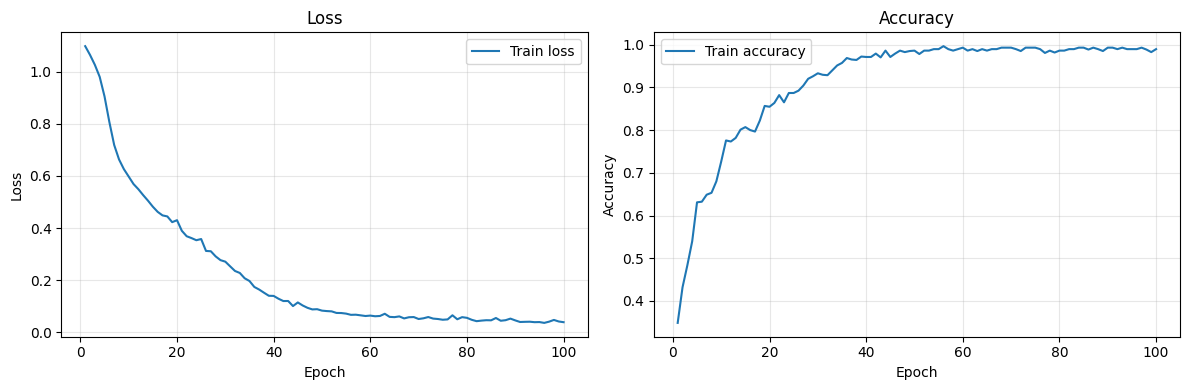

In [23]:
epochs = range(1, len(model.Losses) + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, model.Losses, label="Train loss")
if getattr(model, "Val_Losses", None) and len(model.Val_Losses) > 0:
    plt.plot(epochs, model.Val_Losses, label="Val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, model.Accuracies, label="Train accuracy")
if getattr(model, "Val_Accuracies", None) and len(model.Val_Accuracies) > 0:
    plt.plot(epochs, model.Val_Accuracies, label="Val accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
logist_test = model.forward(X_test).cpu()
y_true = y_test.cpu()
print(f"Độ chính xác của mô hình trên tập Test: {model.get_accuracy(logist_test, y_true):.4f}")
print(f"Loss của mô hình trên tập test: {model.compute_loss(logist_test, y_true):.4f}")

Độ chính xác của mô hình trên tập Test: 1.0000
Loss của mô hình trên tập test: 0.0270
